In [44]:
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
data = pd.read_csv("temperature_regulation_smart_manufacturing.csv")
data.head(10)

,Timestamp,Current Temperature (°C),Setpoint Temperature (°C),Temperature Error (°C),PID Control Output (%),Fuzzy PID Control Output (%),Overshoot (°C),Response Time (s),Steady-State Error (°C),Ambient Temperature (°C),Humidity (%),PID Kp,PID Ki,PID Kd,Fuzzy Rule Base Parameters
0,2025-01-31 12:09:12.524887,368.727006,400,31.272994,67.405317,65.022374,6.727030,47.159876,0.787271,23.944771,50.387995,1.220268,0.465431,0.249456,2
1,2025-01-31 12:14:12.524887,397.535715,400,2.464285,81.676038,79.145826,7.966814,54.162970,0.946871,22.517159,51.867725,1.187283,0.310144,0.233165,0
2,2025-01-31 12:19:12.524887,386.599697,400,13.400303,94.917833,98.980379,2.504679,52.804828,1.709095,24.617184,58.312458,0.595754,0.389964,0.170462,0
3,2025-01-31 12:24:12.524887,379.932924,400,20.067076,89.288995,86.784457,6.248741,34.616997,0.680009,23.839349,57.667684,1.422572,0.274419,0.342907,1
4,2025-01-31 12:29:12.524887,357.800932,400,42.199068,92.262446,89.981943,5.717460,34.477484,1.739299,22.471612,53.506427,1.068472,0.352014,0.290650,2
5,2025-01-31 12:34:12.524887,357.799726,400,42.200274,86.351335,88.945317,8.328304,38.045231,0.176269,24.887014,53.768106,0.863726,0.236230,0.446280,2
6,2025-01-31 12:39:12.524887,352.904181,400,47.095819,87.691063,87.188461,9.060871,40.832242,1.553597,23.555096,55.335544,1.256539,0.220464,0.112844,2
7,2025-01-31 12:44:12.524887,393.308807,400,6.691193,93.967826,96.734932,0.121568,42.253667,1.695095,22.218695,50.002410,0.757365,0.331292,0.357547,2
8,2025-01-31 12:49:12.524887,380.055751,400,19.944249,69.986720,65.640382,6.740199,50.390917,0.363635,23.880499,52.412443,1.193510,0.299252,0.405180,2
9,2025-01-31 12:54:12.524887,385.403629,400,14.596371,79.576999,79.452710,0.518358,31.700413,0.860693,22.759597,52.082318,0.539711,0.331815,0.403795,2


In [46]:
# Convert to relative time measurement from the t0, format YYYY-MM-DD HH:mm:ss.######
data["Timestamp"] = pd.to_datetime(
    data["Timestamp"],
    format="%Y-%m-%d %H:%M:%S.%f"
)

t0 = data["Timestamp"].iloc[0]
data["time_seconds"] = (data["Timestamp"] - t0).dt.total_seconds().astype(int)
data = data.drop(columns=['Timestamp'])
data.head(10)

,Current Temperature (°C),Setpoint Temperature (°C),Temperature Error (°C),PID Control Output (%),Fuzzy PID Control Output (%),Overshoot (°C),Response Time (s),Steady-State Error (°C),Ambient Temperature (°C),Humidity (%),PID Kp,PID Ki,PID Kd,Fuzzy Rule Base Parameters,time_seconds
0,368.727006,400,31.272994,67.405317,65.022374,6.727030,47.159876,0.787271,23.944771,50.387995,1.220268,0.465431,0.249456,2,0
1,397.535715,400,2.464285,81.676038,79.145826,7.966814,54.162970,0.946871,22.517159,51.867725,1.187283,0.310144,0.233165,0,300
2,386.599697,400,13.400303,94.917833,98.980379,2.504679,52.804828,1.709095,24.617184,58.312458,0.595754,0.389964,0.170462,0,600
3,379.932924,400,20.067076,89.288995,86.784457,6.248741,34.616997,0.680009,23.839349,57.667684,1.422572,0.274419,0.342907,1,900
4,357.800932,400,42.199068,92.262446,89.981943,5.717460,34.477484,1.739299,22.471612,53.506427,1.068472,0.352014,0.290650,2,1200
5,357.799726,400,42.200274,86.351335,88.945317,8.328304,38.045231,0.176269,24.887014,53.768106,0.863726,0.236230,0.446280,2,1500
6,352.904181,400,47.095819,87.691063,87.188461,9.060871,40.832242,1.553597,23.555096,55.335544,1.256539,0.220464,0.112844,2,1800
7,393.308807,400,6.691193,93.967826,96.734932,0.121568,42.253667,1.695095,22.218695,50.002410,0.757365,0.331292,0.357547,2,2100
8,380.055751,400,19.944249,69.986720,65.640382,6.740199,50.390917,0.363635,23.880499,52.412443,1.193510,0.299252,0.405180,2,2400
9,385.403629,400,14.596371,79.576999,79.452710,0.518358,31.700413,0.860693,22.759597,52.082318,0.539711,0.331815,0.403795,2,2700


In [47]:
data.describe()

,Current Temperature (°C),Setpoint Temperature (°C),Temperature Error (°C),PID Control Output (%),Fuzzy PID Control Output (%),Overshoot (°C),Response Time (s),Steady-State Error (°C),Ambient Temperature (°C),Humidity (%),PID Kp,PID Ki,PID Kd,Fuzzy Rule Base Parameters,time_seconds
count,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,374.512828,400.0,25.487172,80.280692,80.304749,4.903750,44.823160,0.996929,23.479927,54.823706,0.986497,0.298718,0.302277,1.040000,149850.000000
std,14.606868,0.0,14.606868,11.687596,12.120289,2.864893,8.604298,0.578390,0.869201,2.849144,0.282235,0.112861,0.114581,0.817966,86645.830829
min,350.231601,400.0,0.014116,60.128731,55.847321,0.006534,30.000922,0.012368,22.004285,50.002410,0.500243,0.100021,0.100377,0.000000,0.000000
25%,361.798663,400.0,12.784021,69.642971,69.714277,2.419008,37.349220,0.498760,22.720665,52.359893,0.749384,0.205658,0.201052,0.000000,74925.000000
50%,374.840369,400.0,25.159631,80.749356,81.088329,4.842793,44.837943,0.980806,23.453929,54.839907,0.978701,0.298075,0.302546,1.000000,149850.000000
75%,387.215979,400.0,38.201337,90.418602,89.969080,7.375408,52.199804,1.479704,24.269393,57.144663,1.215905,0.394487,0.402681,2.000000,224775.000000
max,399.985884,400.0,49.768399,99.976549,104.207067,9.995577,59.932482,1.998701,24.998382,59.989047,1.496013,0.499802,0.499869,2.000000,299700.000000


In [48]:
gap = data['time_seconds'].diff().value_counts()
print(gap)

time_seconds
300.0    999
Name: count, dtype: int64


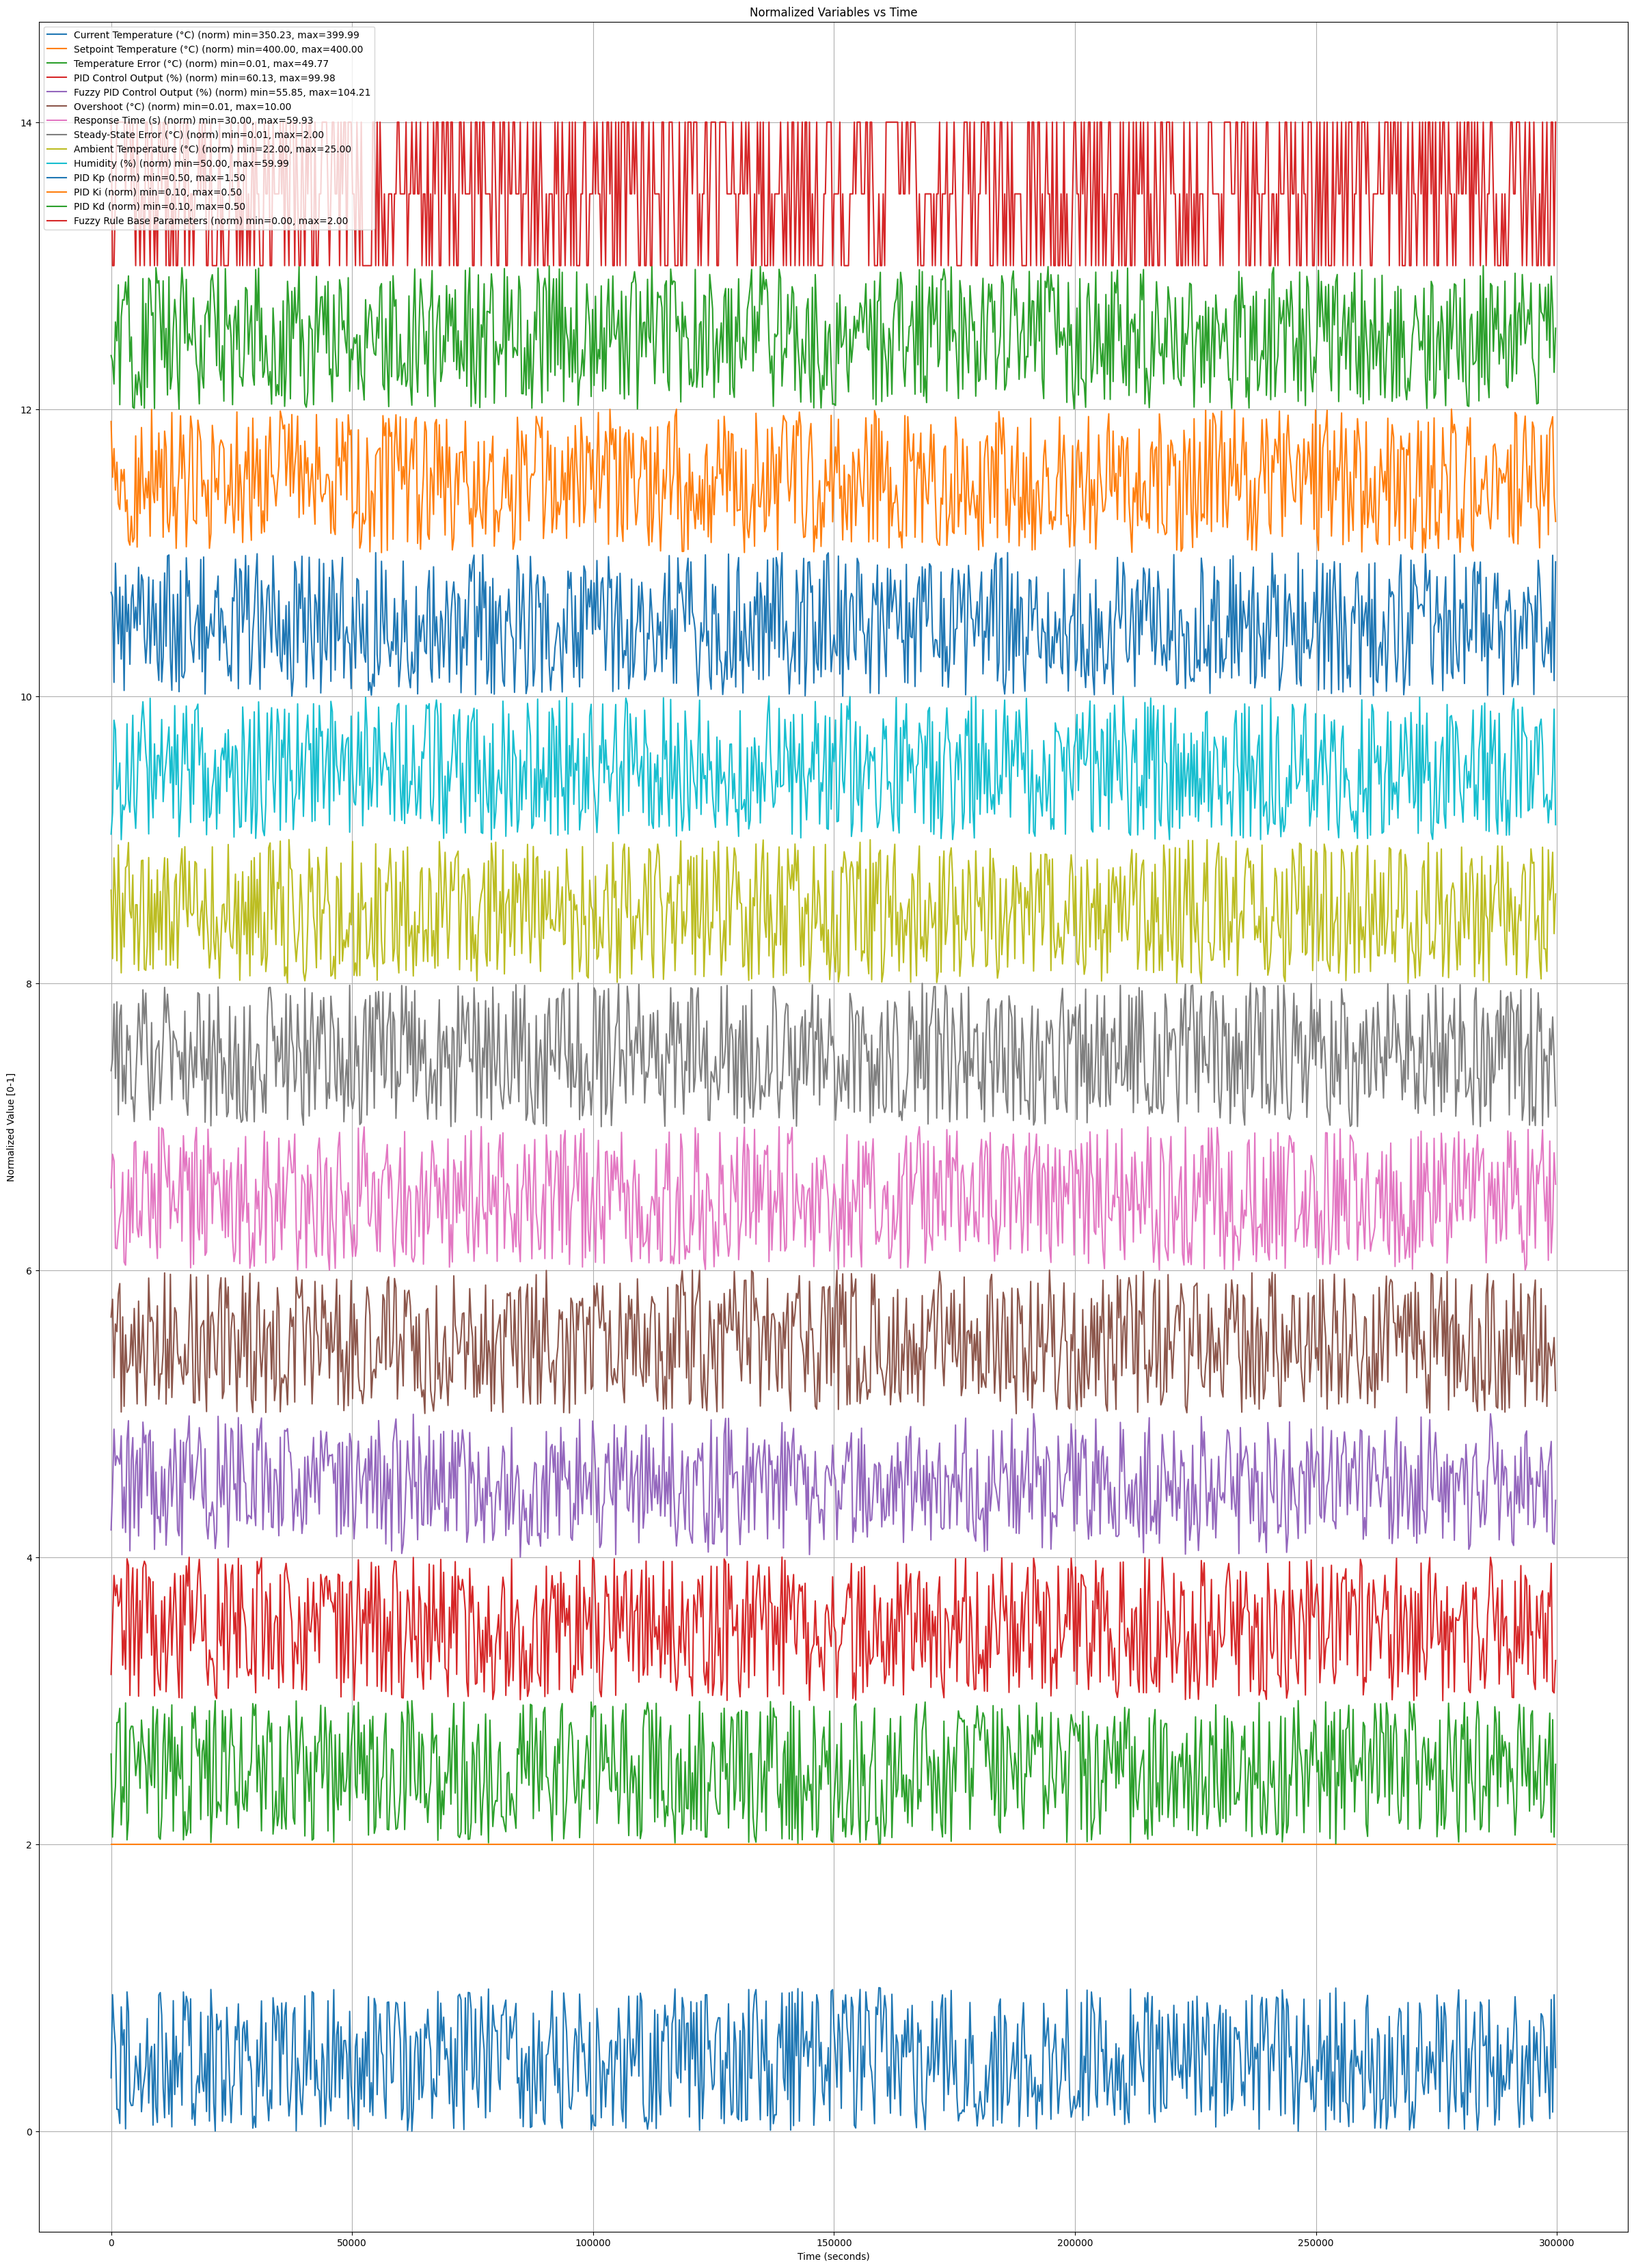

In [ ]:
num = len(data.columns.to_list()) - 1
plt.figure(figsize=(30, 3*num))

for idx, i in enumerate(range(num)):
    col = data.columns[i]
    
    # Min-max normalization
    min_val = data[col].min()
    max_val = data[col].max()
    
    if min_val < max_val:
        normalized = (data[col] - min_val) / (max_val - min_val) + idx
    else:
        normalized = data[col]/max_val + idx
    
    # Label with original scale for reconstruction
    label = f"{col} (norm) min={min_val:.2f}, max={max_val:.2f}"
    
    plt.plot(data["time_seconds"], normalized, label=label)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Value [0-1]")
plt.title("Normalized Variables vs Time")
plt.legend()
plt.grid(True)
plt.show()

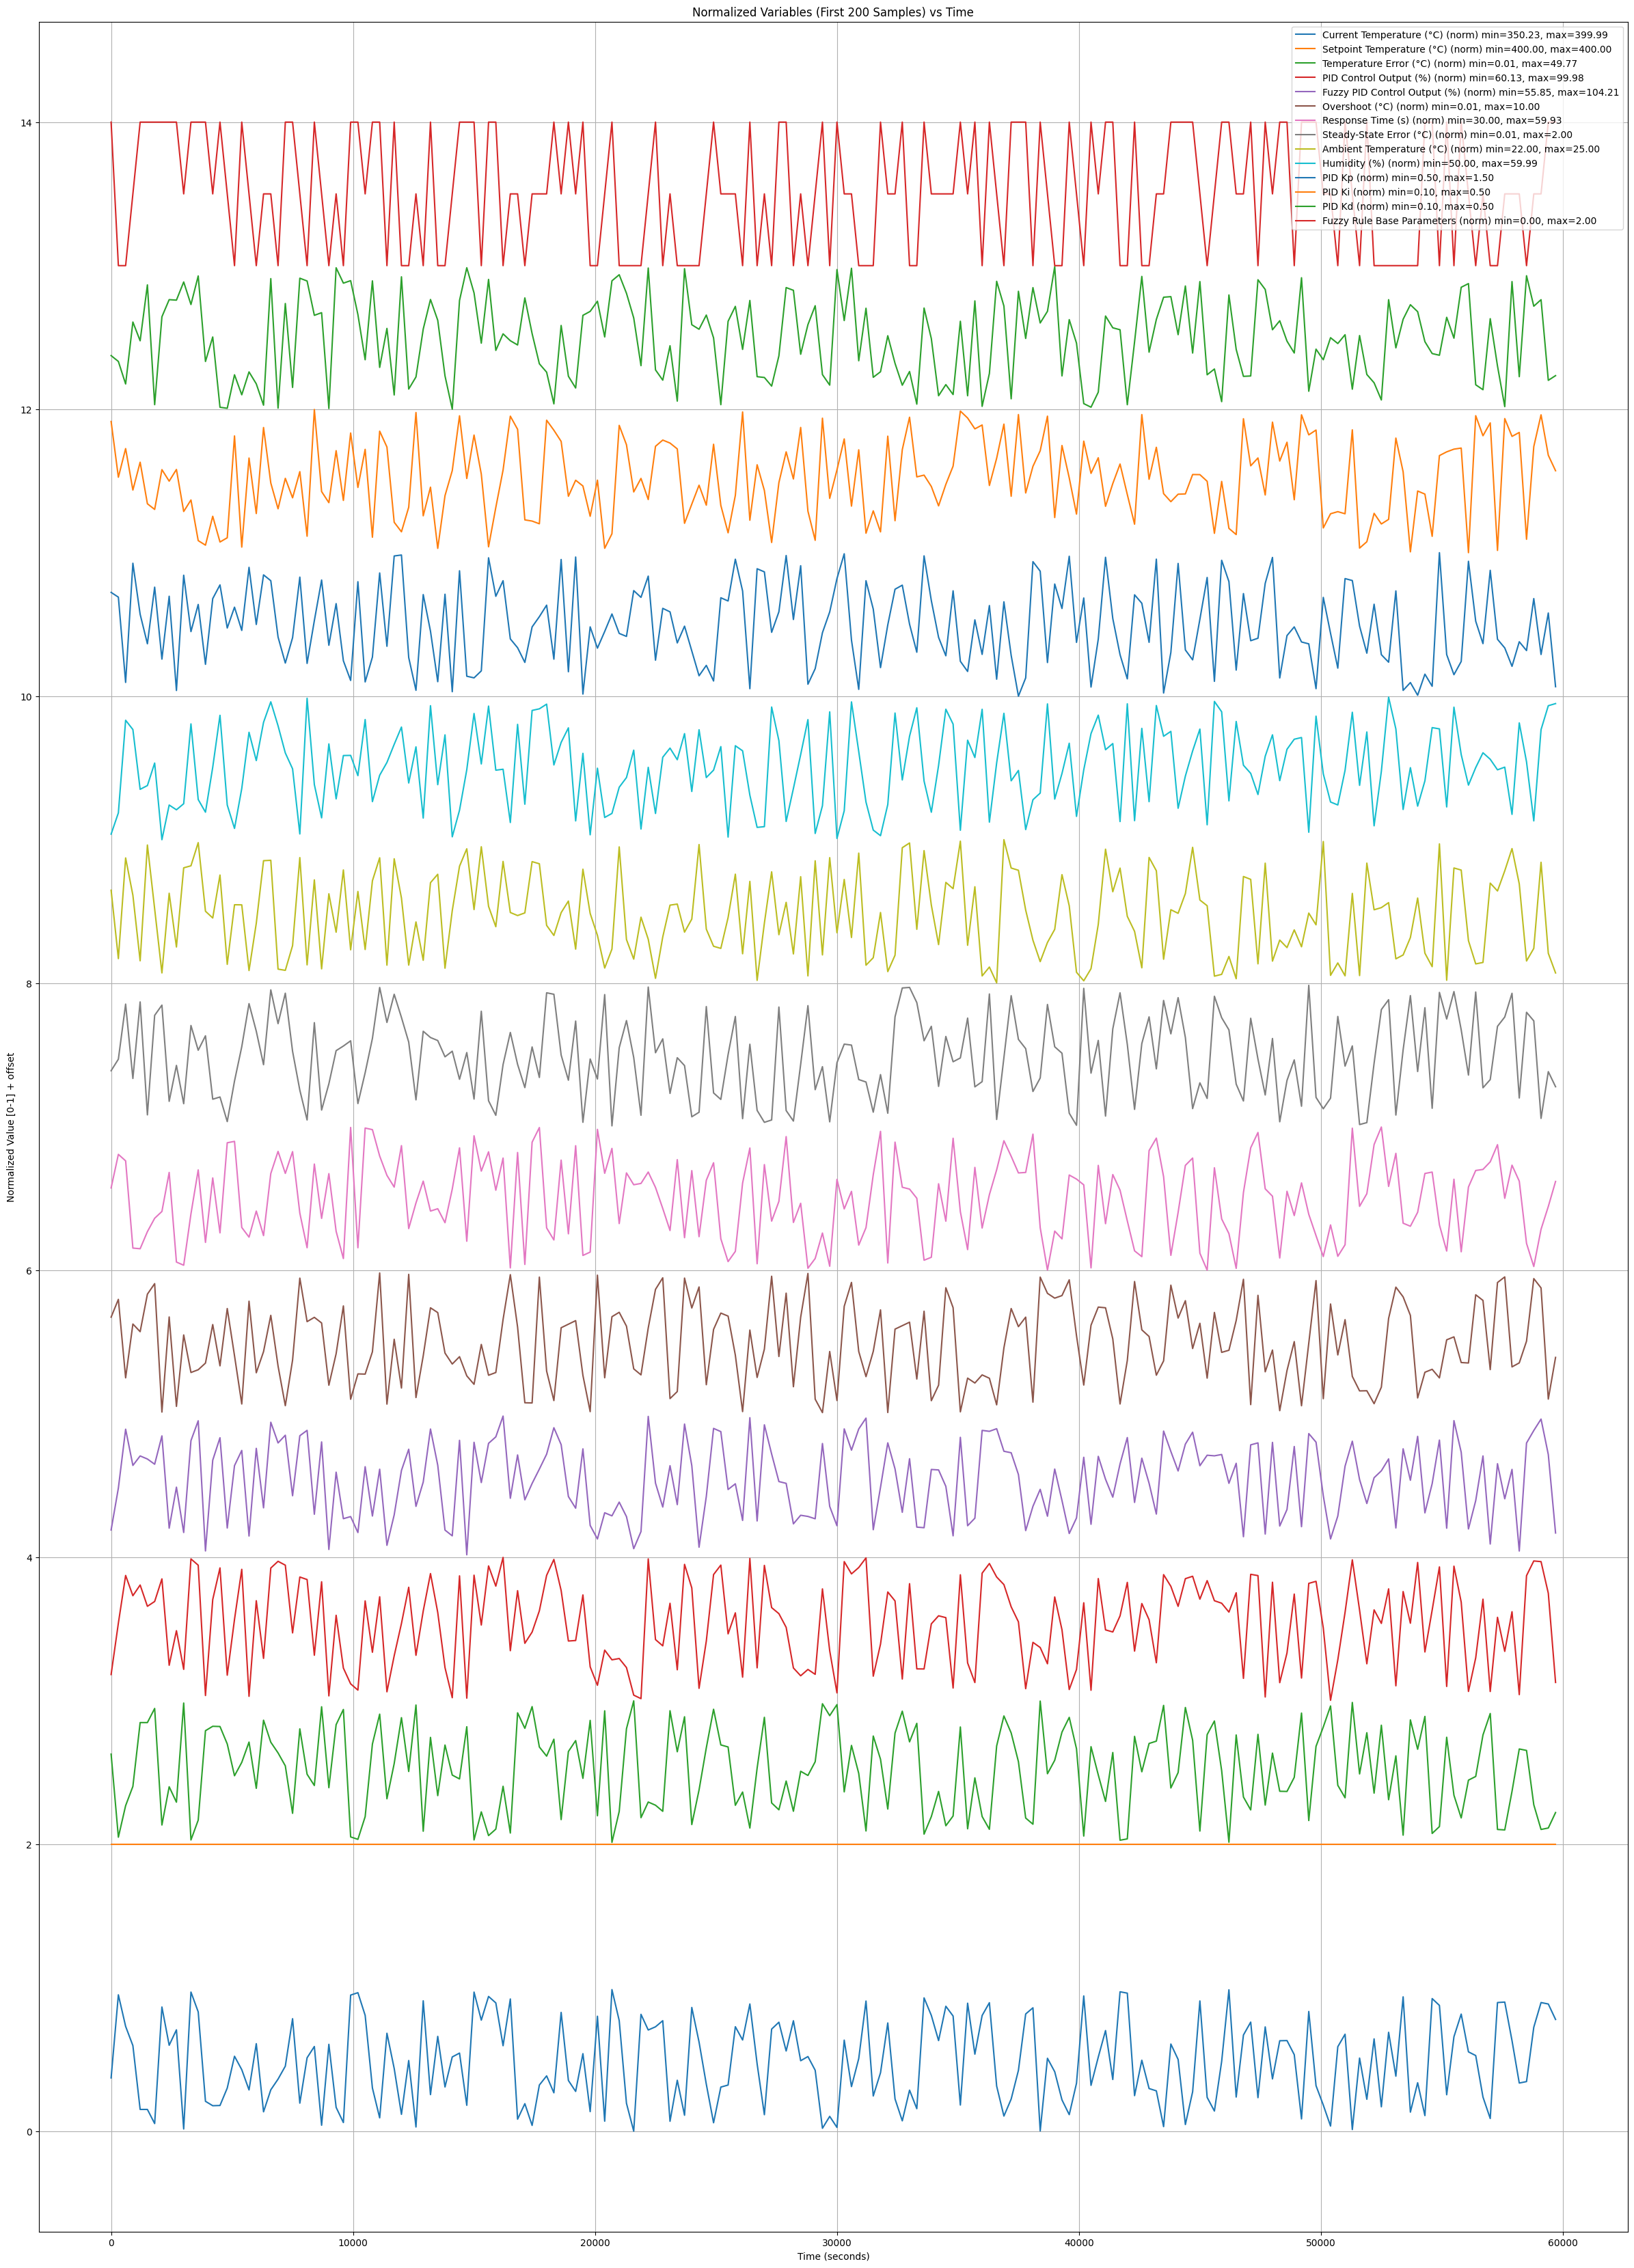

In [56]:
plt.figure(figsize=(30, 3*num))

# Slice first n samples
num_samples = 200
data_slice = data.iloc[:num_samples]

for idx, i in enumerate(range(num)):
    col = data.columns[i]
    
    # Min-max normalization
    min_val = data[col].min()
    max_val = data[col].max()
    
    if min_val < max_val:
        normalized = (data_slice[col] - min_val) / (max_val - min_val) + idx
    else:
        normalized = data_slice[col]/max_val + idx  # handle constant column
    
    # Label with original scale for reconstruction
    label = f"{col} (norm) min={min_val:.2f}, max={max_val:.2f}"
    
    plt.plot(data_slice["time_seconds"], normalized, label=label)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Value [0-1] + offset")
plt.title(f"Normalized Variables (First {num_samples} Samples) vs Time")
plt.legend()
plt.grid(True)
plt.show()


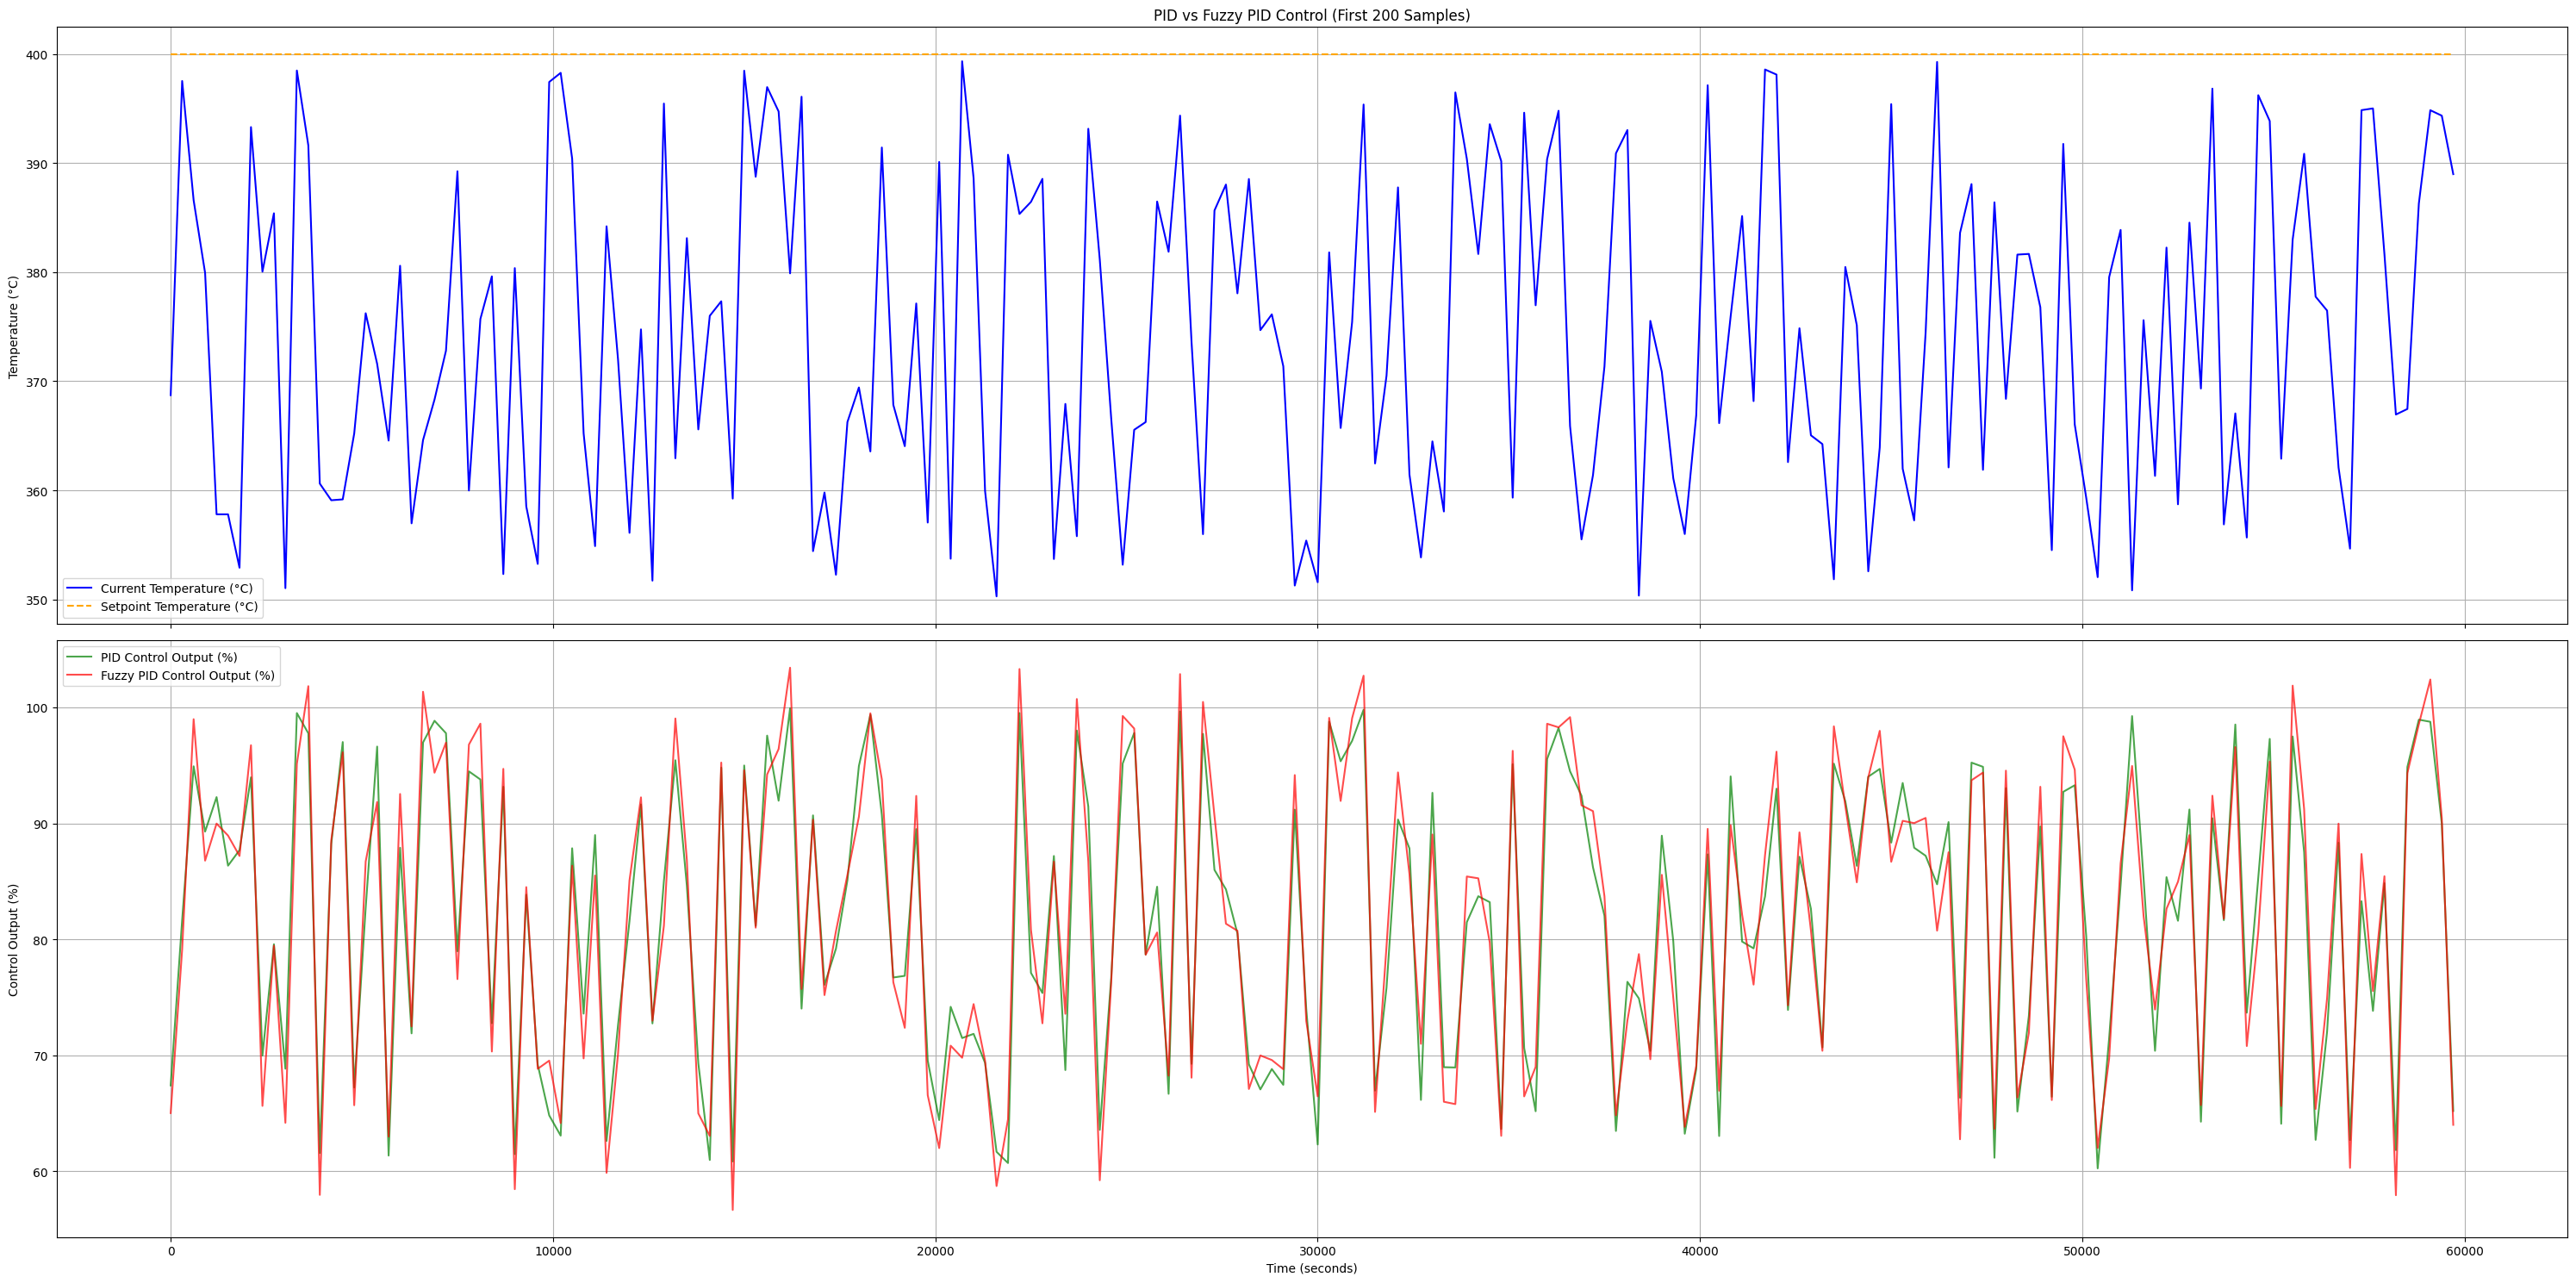

In [66]:
import matplotlib.pyplot as plt

# Slice the first 200 samples
data_slice = data.iloc[:200]


fig, axs = plt.subplots(2, 1, figsize=(30, 15), sharex=True)  # sharex to align time axis
# Plot Current Temperature vs Setpoint
axs[0].plot(data_slice["time_seconds"], data_slice["Current Temperature (°C)"], label="Current Temperature (°C)", color="blue")
axs[0].plot(data_slice["time_seconds"], data_slice["Setpoint Temperature (°C)"], label="Setpoint Temperature (°C)", color="orange", linestyle="--")
axs[0].set_ylabel("Temperature (°C)")
axs[0].set_title("PID vs Fuzzy PID Control (First 200 Samples)")
axs[0].legend()
axs[0].grid(True)

# Plot PID and Fuzzy PID control outputs
axs[1].plot(data_slice["time_seconds"], data_slice["PID Control Output (%)"], label="PID Control Output (%)", color="green", alpha=0.7)
axs[1].plot(data_slice["time_seconds"], data_slice["Fuzzy PID Control Output (%)"], label="Fuzzy PID Control Output (%)", color="red", alpha=0.7)
axs[1].set_xlabel("Time (seconds)")
axs[1].set_ylabel("Control Output (%)")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()  # adjusts spacing to prevent overlap
plt.show()


The dataset contains information about a thermal control system. In terms of system control, thermal control system is definitely a first order system that has a direct interaction to the ambient temperature and faces disturbance of humidity. The aim of this system is to keep the system to 400 degree Celcius and the data is updated every 300 seconds. There are 2 controllers implemented in this first-order thermal control system: PID and fuzzy control with 3 stages. 